In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

# Graph style
plt.style.use("ggplot")

In [2]:
df = pd.read_csv(r"C:\SalesForecasting_Kamali\train.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.shape

(9800, 18)

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [7]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [8]:
df.isnull().sum()

Row ID          0
Order ID        0
Order Date      0
Ship Date       0
Ship Mode       0
               ..
Product ID      0
Category        0
Sub-Category    0
Product Name    0
Sales           0
Length: 18, dtype: int64

In [9]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing.sort_values(by="Percentage", ascending=False)

,Missing Values,Percentage
Postal Code,11,0.112245
Row ID,0,0.000000
Order ID,0,0.000000
Order Date,0,0.000000
Ship Mode,0,0.000000
...,...,...
Product ID,0,0.000000
Category,0,0.000000
Sub-Category,0,0.000000
Product Name,0,0.000000


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()

In [12]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [13]:
df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [14]:
df.dtypes

Row ID                   int64
Order ID                   str
Order Date      datetime64[us]
Ship Date       datetime64[us]
Ship Mode                  str
                     ...      
Product ID                 str
Category                   str
Sub-Category               str
Product Name               str
Sales                  float64
Length: 18, dtype: object

In [15]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Quarter"] = df["Order Date"].dt.quarter
df["Week"] = df["Order Date"].dt.isocalendar().week
df["Day"] = df["Order Date"].dt.day_name()

In [16]:
def season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(season)

In [17]:
df[["Order Date", "Year", "Month", "Month Name", "Quarter", "Week", "Day", "Season"]].head()

,Order Date,Year,Month,Month Name,Quarter,Week,Day,Season
0,2017-11-08,2017,11,November,4,45,Wednesday,Autumn
1,2017-11-08,2017,11,November,4,45,Wednesday,Autumn
2,2017-06-12,2017,6,June,2,24,Monday,Summer
3,2016-10-11,2016,10,October,4,41,Tuesday,Autumn
4,2016-10-11,2016,10,October,4,41,Tuesday,Autumn


In [18]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


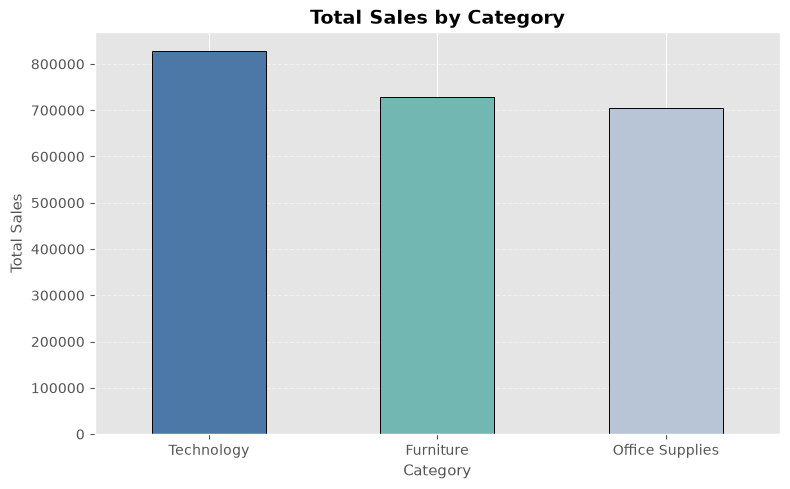

In [19]:
plt.figure(figsize=(8,5))

category_sales.plot(
    kind="bar",
    color=["#4C78A8", "#72B7B2", "#B8C5D6"],
    edgecolor="black",
    linewidth=0.7
)

plt.title("Total Sales by Category", fontsize=14, fontweight="bold")
plt.xlabel("Category", fontsize=11)
plt.ylabel("Total Sales", fontsize=11)

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("C:/SalesForecasting_Kamali/charts/category_sales.png", dpi=300)
plt.show()

In [20]:
subcat_sales = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(subcat_sales)

Sub-Category
Phones       327782.448
Chairs       322822.731
Storage      219343.392
Tables       202810.628
Binders      200028.785
                ...    
Supplies      46420.308
Art           26705.410
Envelopes     16128.046
Labels        12347.726
Fasteners      3001.960
Name: Sales, Length: 17, dtype: float64


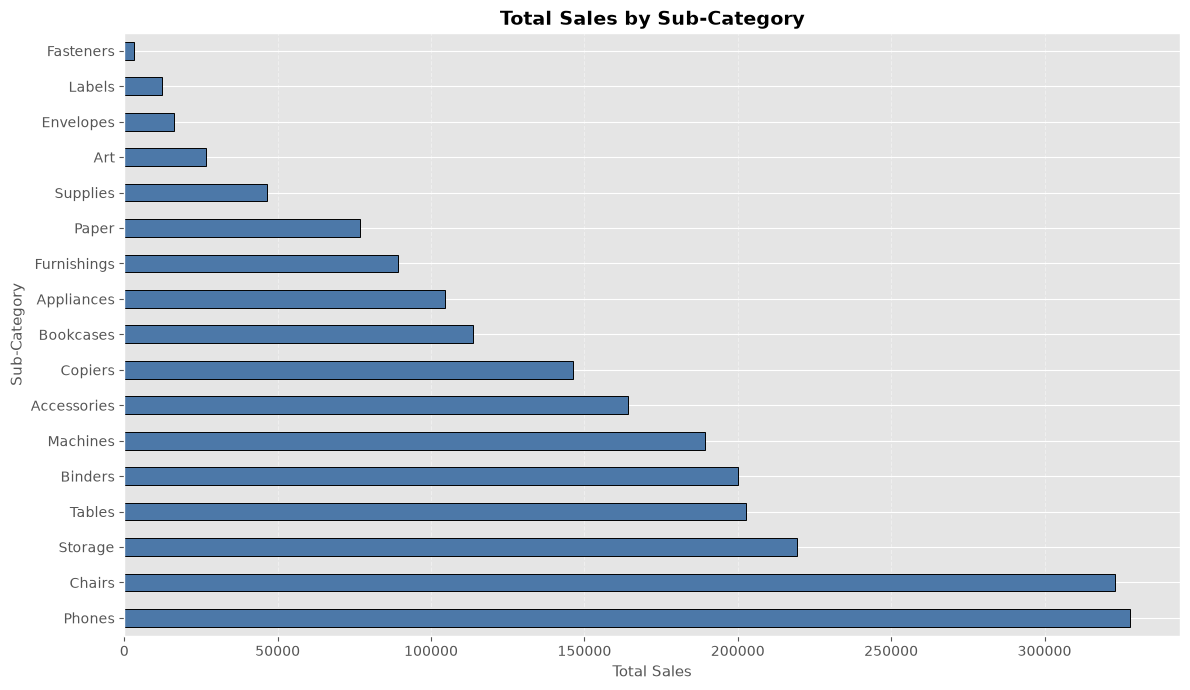

In [21]:
plt.figure(figsize=(12,7))

subcat_sales.plot(
    kind="barh",
    color="#4C78A8",
    edgecolor="black",
    linewidth=0.7
)

plt.title("Total Sales by Sub-Category", fontsize=14, fontweight="bold")
plt.xlabel("Total Sales", fontsize=11)
plt.ylabel("Sub-Category", fontsize=11)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("C:/SalesForecasting_Kamali/charts/subcategory_sales.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation
- Phones generated the highest total sales (327,782.45), making them the top-performing sub-category.
- Chairs followed closely with sales of 322,822.73.
- Storage, Tables, and Binders were also among the highest revenue-generating sub-categories.
- Fasteners, Labels, Envelopes, and Art contributed the least to overall sales.
- These insights suggest that high-performing sub-categories such as Phones and Chairs should receive greater focus during demand forecasting and inventory planning.

In [22]:
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(region_sales)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


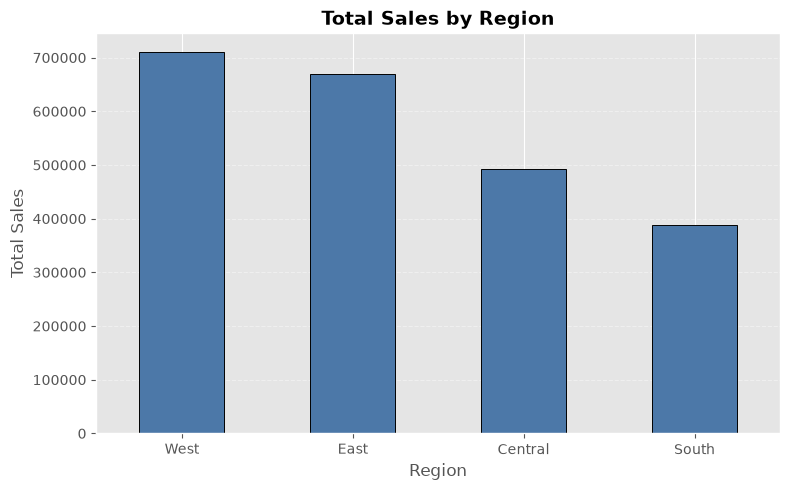

In [23]:
plt.figure(figsize=(8,5))

region_sales.plot(
    kind="bar",
    color="#4C78A8",
    edgecolor="black",
    linewidth=0.7
)

plt.title("Total Sales by Region", fontsize=14, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig("C:/SalesForecasting_Kamali/charts/region_sales.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation
- The West region generated the highest sales, with total revenue of **710,219.68**.
- The East region ranked second, contributing **669,518.73** in sales.
- The Central and South regions generated comparatively lower sales, with the South region recording the lowest revenue (**389,151.46**).
- The strong performance of the West and East regions indicates higher customer demand and market potential, making them key focus areas for inventory planning and future sales forecasting.

In [24]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Year', 'Month', 'Month Name', 'Quarter',
       'Week', 'Day', 'Season'],
      dtype='str')


In [25]:
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [26]:
df[["Order Date", "Ship Date", "Shipping Days"]].head()

,Order Date,Ship Date,Shipping Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [27]:
shipping_region = (
    df.groupby("Region")["Shipping Days"]
      .mean()
      .sort_values()
)

print(shipping_region)

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64


### Observation
- The **East** region has the lowest average shipping time (**3.91 days**), indicating the fastest order fulfillment.
- The **West** and **South** regions have similar average shipping times, around **3.93–3.96 days**.
- The **Central** region has the highest average shipping time (**4.07 days**), suggesting comparatively slower deliveries.
- Although the differences are small, improving shipping efficiency in the Central region could enhance customer satisfaction and reduce delivery delays.

In [28]:
monthly_pattern = (
    df.groupby("Month Name")["Sales"]
      .mean()
)

In [29]:
monthly_pattern = (
    df.groupby("Month Name")["Sales"]
      .mean()
)

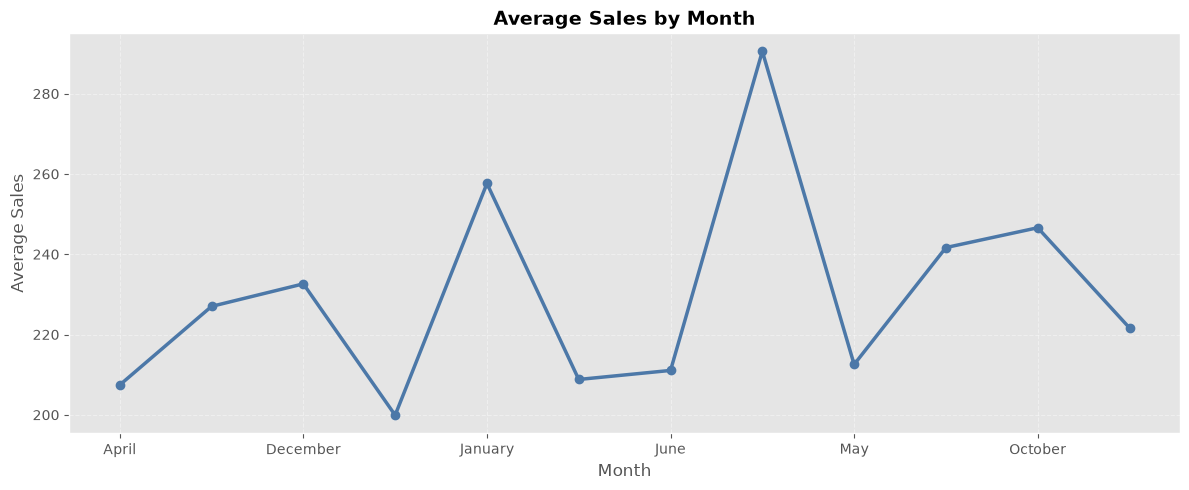

In [30]:
plt.figure(figsize=(12,5))

monthly_pattern.plot(
    kind="line",
    marker="o",
    linewidth=2.5,
    color="#4C78A8"
)

plt.title("Average Sales by Month", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig("C:/SalesForecasting_Kamali/charts/monthly_pattern.png", dpi=300, bbox_inches="tight")

plt.show()

In [31]:
monthly_ts = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
)

monthly_ts.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

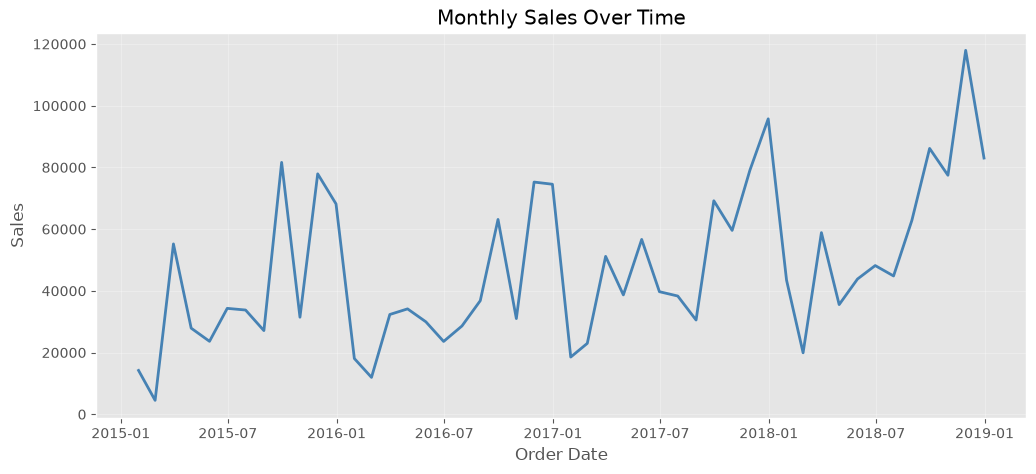

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(monthly_ts,color="steelblue", linewidth=2)

plt.title("Monthly Sales Over Time")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.grid(alpha=0.3)

plt.show()

In [33]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    monthly_ts,
    model="additive",
    period=12
)

decomposition

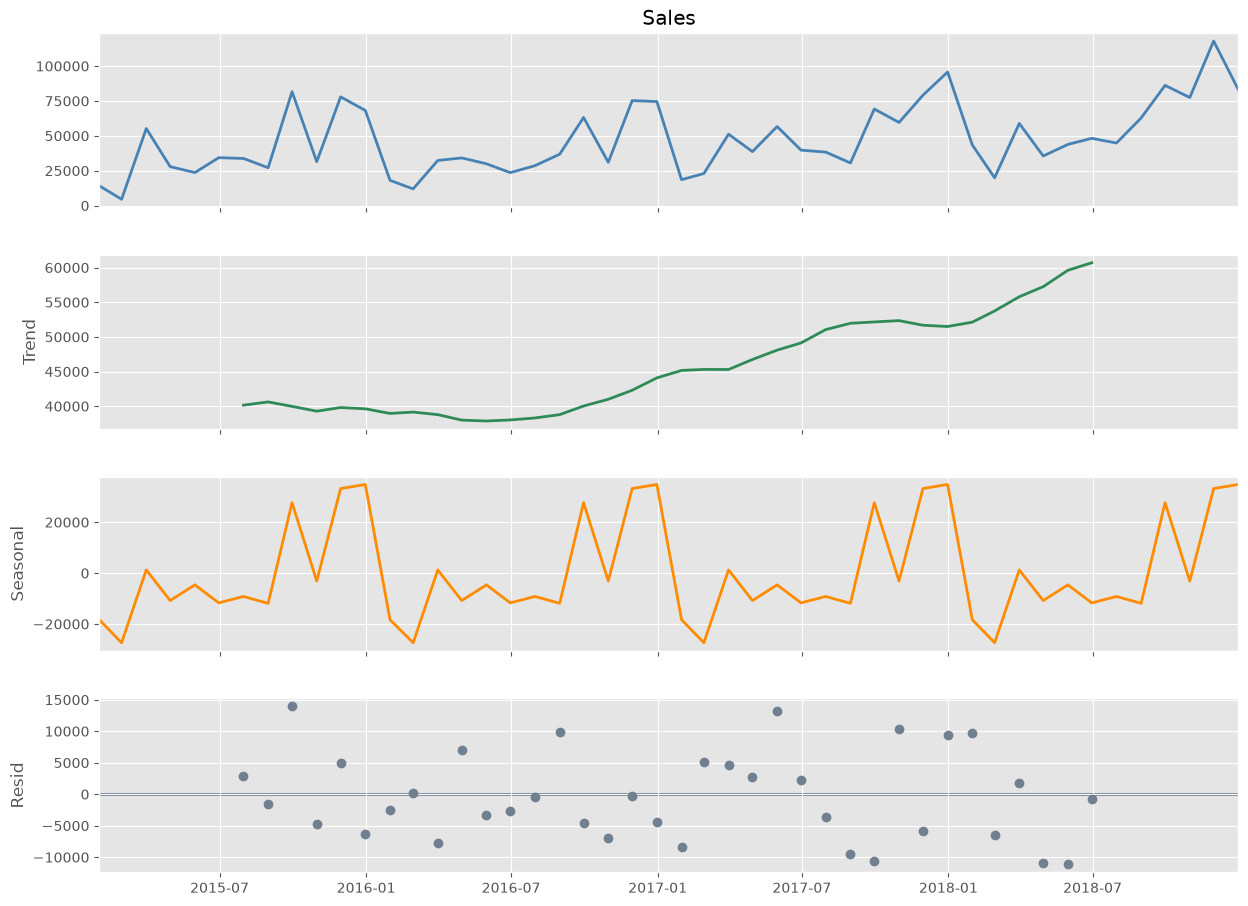

In [34]:
fig = decomposition.plot()
fig.set_size_inches(14, 10)

colors = ["steelblue", "seagreen", "darkorange", "slategray"]

for ax, color in zip(fig.axes, colors):
    for line in ax.get_lines():
        line.set_color(color)
        line.set_linewidth(2)

plt.savefig(
    "C:/SalesForecasting_Kamali/charts/sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_ts)

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -4.41613676143077
p-value: 0.00027791039276670493
Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


The Augmented Dickey-Fuller (ADF) test was performed to determine whether the monthly sales time series is stationary. The p-value (0.000278) is less than the significance level of 0.05, and the ADF statistic (-4.416) is more negative than the critical values at the 1%, 5%, and 10% levels. Therefore, the null hypothesis is rejected, indicating that the monthly sales series is stationary and suitable for ARIMA/SARIMA modeling without additional differencing.

In [36]:
monthly_diff = monthly_ts.diff()

monthly_diff.head()

Order Date
2015-01-31          NaN
2015-02-28    -9685.815
2015-03-31    50685.905
2015-04-30   -27298.942
2015-05-31    -4262.552
Freq: ME, Name: Sales, dtype: float64

In [37]:
monthly_diff = monthly_diff.dropna()

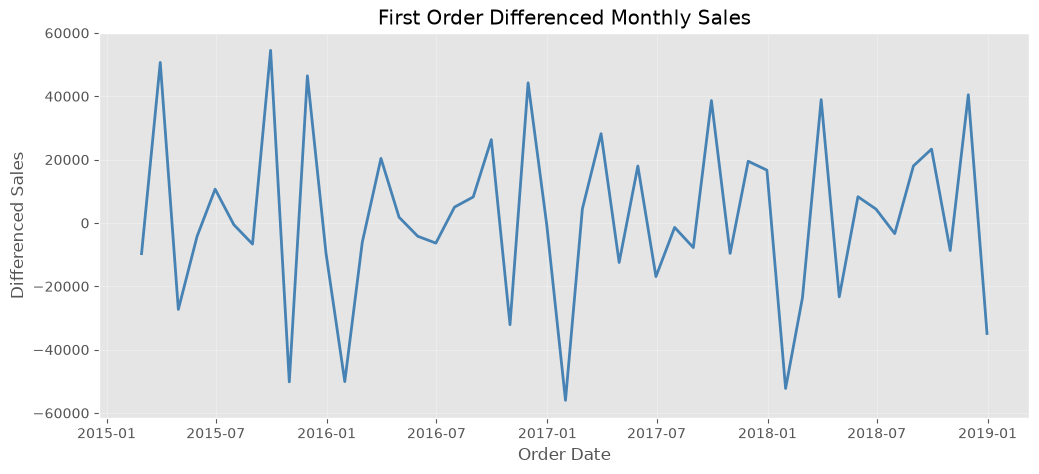

In [38]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_diff,
    color="steelblue",
    linewidth=2
)

plt.title("First Order Differenced Monthly Sales")
plt.xlabel("Order Date")
plt.ylabel("Differenced Sales")

plt.grid(alpha=0.3)

plt.savefig(
    "C:/SalesForecasting_Kamali/charts/first_order_differencing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

First-order differencing was performed to demonstrate how differencing transforms a time series by calculating the change between consecutive observations. The resulting series fluctuates around zero without a clear trend, indicating stationarity. However, since the ADF test had already confirmed that the original monthly sales series was stationary, additional differencing is not required for modeling.

<Figure size 1400x500 with 0 Axes>

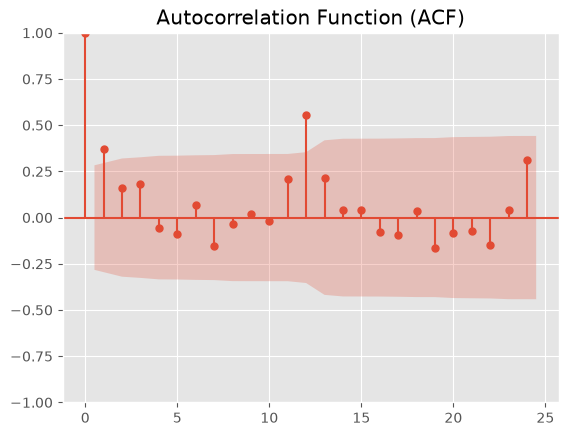

<Figure size 1400x500 with 0 Axes>

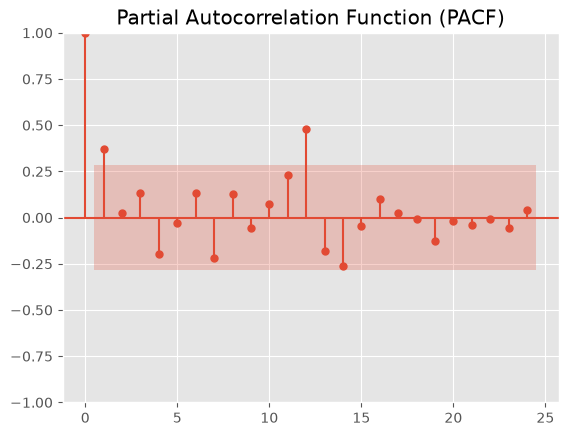

In [39]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(14, 5))
plot_acf(monthly_ts, lags=24)
plt.title("Autocorrelation Function (ACF)")
plt.savefig("C:/SalesForecasting_Kamali/charts/acf_plot.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(14, 5))
plot_pacf(monthly_ts, lags=24, method="ywm")
plt.title("Partial Autocorrelation Function (PACF)")
plt.savefig("C:/SalesForecasting_Kamali/charts/pacf_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [40]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [41]:
model = SARIMAX(
    monthly_ts,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 12)
)

In [42]:
sarima_model = model.fit()

C:\Users\ADMIN\anaconda3\envs\forecasting\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\ADMIN\anaconda3\envs\forecasting\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


In [43]:
print(sarima_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   48
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                -541.670
Date:                            Sun, 12 Jul 2026   AIC                           1093.340
Time:                                    20:20:49   BIC                           1102.696
Sample:                                01-31-2015   HQIC                          1096.876
                                     - 12-31-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9571      0.110      8.714      0.000       0.742       1.172
ma.L1         -0.6695      0.409   

In [44]:
predictions = sarima_model.predict(
    start=monthly_ts.index[0],
    end=monthly_ts.index[-1]
)

predictions.head()

Order Date
2015-01-31        0.000000
2015-02-28    11466.629118
2015-03-31     7997.225868
2015-04-30    25313.345356
2015-05-31    25539.597524
Freq: ME, Name: predicted_mean, dtype: float64

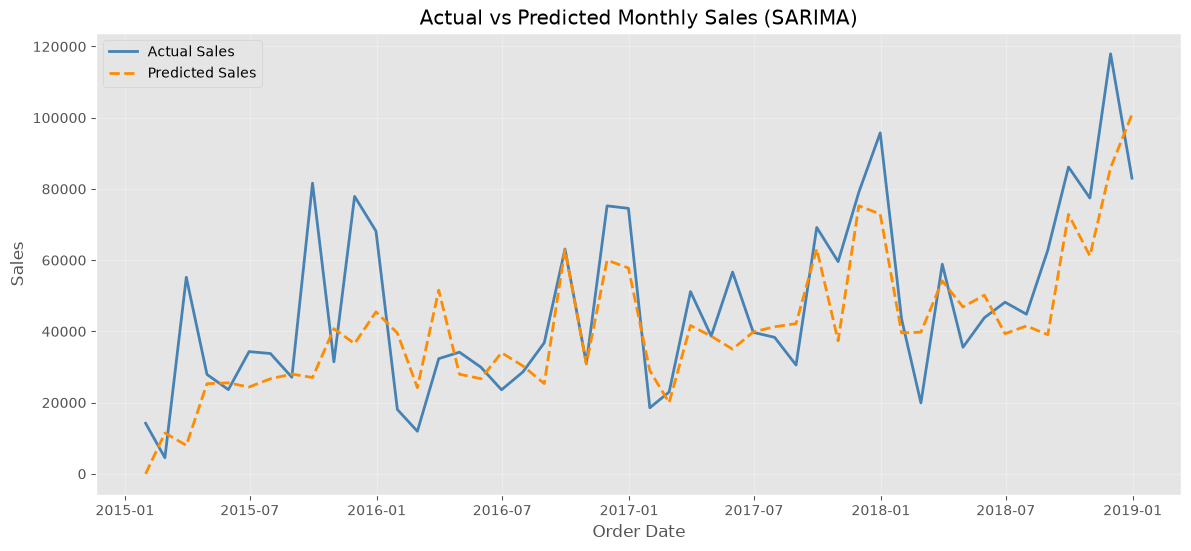

In [45]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_ts,
    label="Actual Sales",
    color="steelblue",
    linewidth=2
)

plt.plot(
    predictions,
    label="Predicted Sales",
    color="darkorange",
    linewidth=2,
    linestyle="--"
)

plt.title("Actual vs Predicted Monthly Sales (SARIMA)")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.savefig(
    "C:/SalesForecasting_Kamali/charts/actual_vs_predicted_sarima.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [47]:
mae = mean_absolute_error(monthly_ts, predictions)

rmse = np.sqrt(mean_squared_error(monthly_ts, predictions))

mape = np.mean(np.abs((monthly_ts - predictions) / monthly_ts)) * 100

In [48]:
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 12761.90
RMSE : 17461.16
MAPE : 33.03%


The SARIMA model was evaluated using MAE, RMSE, and MAPE. The model achieved an MAE of 12,761.90, indicating the average prediction error in monthly sales. The RMSE of 17,461.16 suggests that larger forecasting errors were relatively limited. The MAPE of 33.03% indicates that the model's predictions deviated from the actual sales by approximately 33% on average. These results show that the SARIMA model provides a reasonable baseline forecast for the given retail sales dataset.


In [49]:
forecast = sarima_model.get_forecast(steps=12)

forecast_values = forecast.predicted_mean
confidence_intervals = forecast.conf_int()

print(forecast_values)

2019-01-31    54982.919121
2019-02-28    42670.121527
2019-03-31    67741.345340
2019-04-30    52659.051282
2019-05-31    58217.698130
                  ...     
2019-08-31    60105.128392
2019-09-30    80443.215224
2019-10-31    70043.545952
2019-11-30    96153.106443
2019-12-31    81453.954729
Freq: ME, Name: predicted_mean, Length: 12, dtype: float64


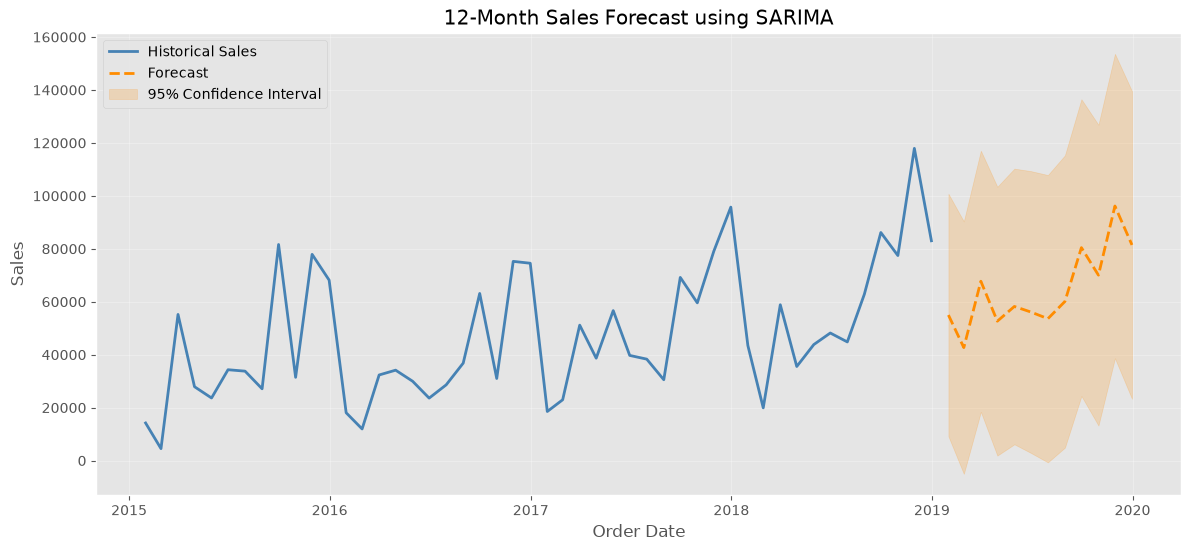

In [50]:
plt.figure(figsize=(14,6))

# Historical data
plt.plot(
    monthly_ts,
    label="Historical Sales",
    color="steelblue",
    linewidth=2
)

# Forecast
plt.plot(
    forecast_values,
    label="Forecast",
    color="darkorange",
    linewidth=2,
    linestyle="--"
)

# Confidence interval
plt.fill_between(
    confidence_intervals.index,
    confidence_intervals.iloc[:, 0],
    confidence_intervals.iloc[:, 1],
    color="darkorange",
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("12-Month Sales Forecast using SARIMA")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "C:/SalesForecasting_Kamali/charts/sarima_12_month_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:
from prophet import Prophet

In [52]:
prophet_df = monthly_ts.reset_index()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [53]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

In [54]:
prophet_model.fit(prophet_df)

20:20:56 - cmdstanpy - INFO - Chain [1] start processing
20:20:57 - cmdstanpy - INFO - Chain [1] done processing


In [55]:
future = prophet_model.make_future_dataframe(
    periods=12,
    freq="ME"
)

future.tail()

,ds
55,2019-08-31
56,2019-09-30
57,2019-10-31
58,2019-11-30
59,2019-12-31


In [56]:
forecast = prophet_model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-31,33505.686141,5076.794060,23408.759716,33505.686141,33505.686141,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,0.0,0.0,0.0,14300.788630
1,2015-02-28,33906.289832,-6475.273974,11598.658891,33906.289832,33906.289832,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,0.0,0.0,0.0,2292.490775
2,2015-03-31,34349.815347,42642.256669,61202.375018,34349.815347,34349.815347,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,0.0,0.0,0.0,52016.921025
3,2015-04-30,34779.033587,11727.258017,30257.639533,34779.033587,34779.033587,-13655.620453,-13655.620453,-13655.620453,-13655.620453,-13655.620453,-13655.620453,0.0,0.0,0.0,21123.413134
4,2015-05-31,35222.559103,14093.234721,31928.751987,35222.559103,35222.559103,-12496.061322,-12496.061322,-12496.061322,-12496.061322,-12496.061322,-12496.061322,0.0,0.0,0.0,22726.497781


In [57]:
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(12)

,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,42990.532202,33344.446621,52099.518240
49,2019-02-28,31248.159922,22864.881855,40707.454106
50,2019-03-31,81267.007772,72437.927093,90648.621233
51,2019-04-30,50658.420141,42088.602211,60261.058221
52,2019-05-31,52555.922387,42983.571070,61836.214955
...,...,...,...,...
55,2019-08-31,55607.488542,45998.544764,65457.356377
56,2019-09-30,101737.653232,92762.951803,110465.900469
57,2019-10-31,69352.209489,60378.006959,78589.711576
58,2019-11-30,112411.174771,103017.915539,122042.669080


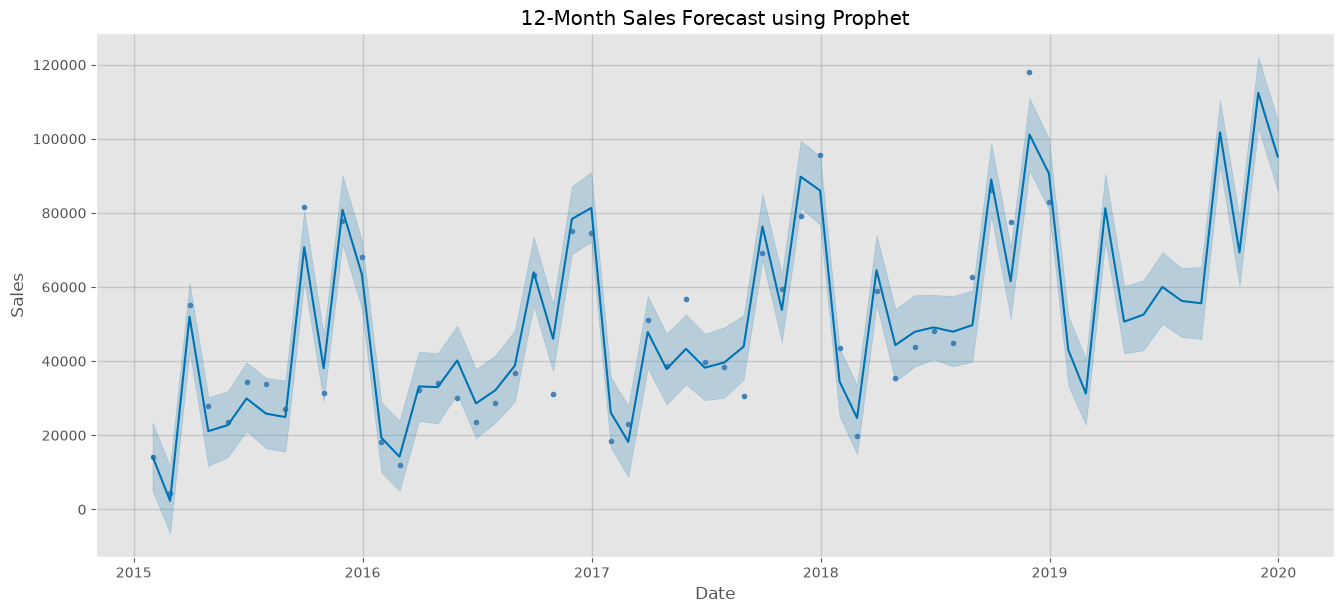

In [58]:
fig = prophet_model.plot(forecast)

fig.set_size_inches(14, 6)

ax = fig.gca()

# Match your previous professional color palette
ax.lines[0].set_color("steelblue")      # Historical + forecast line

# Confidence interval
if len(ax.collections) > 0:
    ax.collections[0].set_alpha(0.2)

plt.title("12-Month Sales Forecast using Prophet")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(alpha=0.3)

plt.savefig(
    "C:/SalesForecasting_Kamali/charts/prophet_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

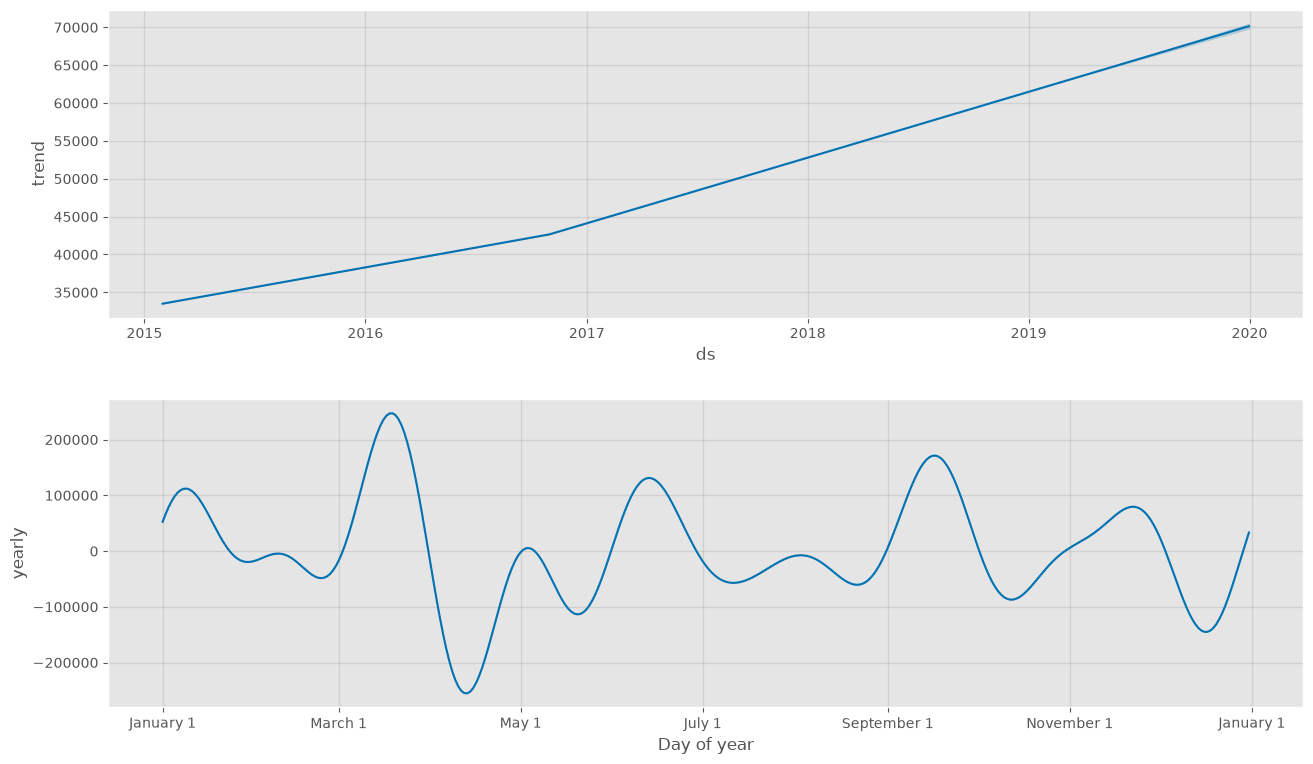

In [59]:
components = prophet_model.plot_components(forecast)

components.set_size_inches(14, 8)

plt.savefig(
    "C:/SalesForecasting_Kamali/charts/prophet_components.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [60]:
prophet_predictions = forecast.iloc[:len(prophet_df)]["yhat"].values
actual = prophet_df["y"].values

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_prophet = mean_absolute_error(actual, prophet_predictions)

rmse_prophet = np.sqrt(mean_squared_error(actual, prophet_predictions))

mape_prophet = np.mean(np.abs((actual - prophet_predictions) / actual)) * 100

In [62]:
print(f"Prophet MAE  : {mae_prophet:.2f}")
print(f"Prophet RMSE : {rmse_prophet:.2f}")
print(f"Prophet MAPE : {mape_prophet:.2f}%")

Prophet MAE  : 5770.42
Prophet RMSE : 7272.00
Prophet MAPE : 14.48%


The Prophet model outperformed the SARIMA model across all evaluation metrics. It achieved a lower MAE (5770.42), RMSE (7272.00), and MAPE (14.48%) compared to SARIMA, demonstrating better forecasting accuracy for the retail sales dataset. Therefore, Prophet was selected as the preferred forecasting model for this project.

In [63]:
ml_df = monthly_ts.to_frame()

ml_df.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [64]:
ml_df["Lag_1"] = ml_df["Sales"].shift(1)
ml_df["Lag_2"] = ml_df["Sales"].shift(2)
ml_df["Lag_3"] = ml_df["Sales"].shift(3)
ml_df["Rolling_Mean_3"] = (
    ml_df["Sales"]
    .rolling(window=3)
    .mean()
    .shift(1)
)

In [65]:
ml_df["Month"] = ml_df.index.month
ml_df["Quarter"] = ml_df.index.quarter

In [66]:
def get_season(month):
    if month in [12, 1, 2]:
        return 0      # Winter
    elif month in [3, 4, 5]:
        return 1      # Spring
    elif month in [6, 7, 8]:
        return 2      # Summer
    else:
        return 3      # Autumn

ml_df["Season"] = ml_df.index.month.map(get_season)

In [67]:
ml_df.head(10)

,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
Order Date,,,,,,,,
2015-01-31,14205.7070,NaN,NaN,NaN,NaN,1,1,0
2015-02-28,4519.8920,14205.7070,NaN,NaN,NaN,2,1,0
2015-03-31,55205.7970,4519.8920,14205.7070,NaN,NaN,3,1,1
2015-04-30,27906.8550,55205.7970,4519.8920,14205.7070,24643.798667,4,2,1
2015-05-31,23644.3030,27906.8550,55205.7970,4519.8920,29210.848000,5,2,1
2015-06-30,34322.9356,23644.3030,27906.8550,55205.7970,35585.651667,6,2,2
2015-07-31,33781.5430,34322.9356,23644.3030,27906.8550,28624.697867,7,3,2
2015-08-31,27117.5365,33781.5430,34322.9356,23644.3030,30582.927200,8,3,2
2015-09-30,81623.5268,27117.5365,33781.5430,34322.9356,31740.671700,9,3,3


In [68]:
ml_df = ml_df.dropna()

ml_df.head()

,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
Order Date,,,,,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,24643.798667,4,2,1
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,29210.848000,5,2,1
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,35585.651667,6,2,2
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,28624.697867,7,3,2
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,30582.927200,8,3,2


In [69]:
X = ml_df.drop(columns=["Sales"])
y = ml_df["Sales"]

In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 36
Testing samples: 9


In [71]:
print(X_train.tail())
print()
print(X_test.head())

                 Lag_1       Lag_2       Lag_3  Rolling_Mean_3  Month  \
Order Date                                                              
2017-11-30  59583.0330  69193.3909  30542.2003    53106.208067     11   
2017-12-31  79066.4958  59583.0330  69193.3909    69280.973233     12   
2018-01-31  95739.1210  79066.4958  59583.0330    78129.549933      1   
2018-02-28  43476.4740  95739.1210  79066.4958    72760.696933      2   
2018-03-31  19920.9974  43476.4740  95739.1210    53045.530800      3   

            Quarter  Season  
Order Date                   
2017-11-30        4       3  
2017-12-31        4       0  
2018-01-31        1       0  
2018-02-28        1       0  
2018-03-31        1       1  

                 Lag_1       Lag_2       Lag_3  Rolling_Mean_3  Month  \
Order Date                                                              
2018-04-30  58863.4128  19920.9974  43476.4740    40753.628067      4   
2018-05-31  35541.9101  58863.4128  19920.9974    38108.77

In [72]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [73]:
xgb_predictions = xgb_model.predict(X_test)

In [74]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_xgb = mean_absolute_error(y_test, xgb_predictions)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_predictions))
mape_xgb = np.mean(np.abs((y_test - xgb_predictions) / y_test)) * 100

print(f"MAE  : {mae_xgb:.2f}")
print(f"RMSE : {rmse_xgb:.2f}")
print(f"MAPE : {mape_xgb:.2f}%")

MAE  : 15198.95
RMSE : 18341.53
MAPE : 21.03%


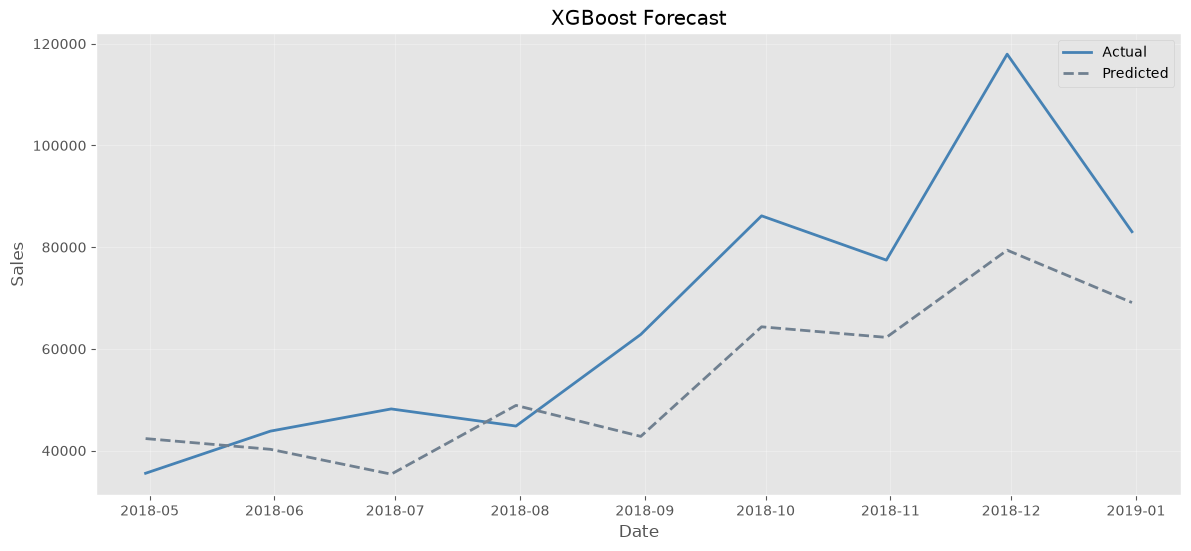

In [75]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.index,
    y_test,
    label="Actual",
    color="steelblue",
    linewidth=2
)

plt.plot(
    y_test.index,
    xgb_predictions,
    label="Predicted",
    color="slategray",
    linestyle="--",
    linewidth=2
)

plt.title("XGBoost Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(alpha=0.3)
plt.legend()

plt.savefig(
    "C:/SalesForecasting_Kamali/charts/xgboost_improved.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [76]:
future = prophet_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

future.tail()

,ds
46,2018-11-30
47,2018-12-31
48,2019-01-31
49,2019-02-28
50,2019-03-31


In [77]:
prophet_forecast = prophet_model.predict(future)

In [78]:
forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail()

,ds,yhat,yhat_lower,yhat_upper
55,2019-08-31,55607.488542,45998.544764,65457.356377
56,2019-09-30,101737.653232,92762.951803,110465.900469
57,2019-10-31,69352.209489,60378.006959,78589.711576
58,2019-11-30,112411.174771,103017.915539,122042.669080
59,2019-12-31,95255.124689,86022.649470,105012.056728


In [79]:
next_3_months = prophet_forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail(3)

In [80]:
next_3_months.to_csv("C:/SalesForecasting_Kamali/next_3_months_forecast.csv", index=False)

In [81]:
prophet_values = next_3_months["yhat"].values

In [82]:
sarima_mae = mae
sarima_rmse = rmse
sarima_mape = mape

prophet_mae = mae_prophet
prophet_rmse = rmse_prophet
prophet_mape = mape_prophet

In [83]:
sarima_forecast = sarima_model.forecast(steps=3)

sarima_forecast

2019-01-31    54982.919121
2019-02-28    42670.121527
2019-03-31    67741.345340
Freq: ME, Name: predicted_mean, dtype: float64

In [84]:
future_dates = pd.date_range(
    start=monthly_ts.index[-1] + pd.offsets.MonthEnd(1),
    periods=3,
    freq="ME"
)

future_xgb = pd.DataFrame(index=future_dates)

In [85]:
future_xgb["Lag_1"] = monthly_ts.iloc[-1]
future_xgb["Lag_2"] = monthly_ts.iloc[-2]
future_xgb["Lag_3"] = monthly_ts.iloc[-3]

future_xgb["Rolling_Mean_3"] = (
    monthly_ts.tail(3).mean()
)

future_xgb["Month"] = future_xgb.index.month
future_xgb["Quarter"] = future_xgb.index.quarter

future_xgb["Season"] = future_xgb.index.month.map(get_season)

In [86]:
future_xgb

,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
2019-01-31,83030.3888,117938.155,77448.1312,92805.558333,1,1,0
2019-02-28,83030.3888,117938.155,77448.1312,92805.558333,2,1,0
2019-03-31,83030.3888,117938.155,77448.1312,92805.558333,3,1,1


In [87]:
xgb_forecast = xgb_model.predict(future_xgb)

xgb_forecast

array([42298.277, 42304.387, 42402.363], dtype=float32)

In [88]:
comparison = pd.DataFrame({

    "Model": [
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE": [
        mae,
        mae_prophet,
        mae_xgb
    ],

    "RMSE": [
        rmse,
        rmse_prophet,
        rmse_xgb
    ],

    "MAPE": [
        mape,
        mape_prophet,
        mape_xgb
    ],

    "Forecast Month 1": [
        sarima_forecast.iloc[0],
        forecast["yhat"].iloc[-3],
        xgb_forecast[0]
    ],

    "Forecast Month 2": [
        sarima_forecast.iloc[1],
        forecast["yhat"].iloc[-2],
        xgb_forecast[1]
    ],

    "Forecast Month 3": [
        sarima_forecast.iloc[2],
        forecast["yhat"].iloc[-1],
        xgb_forecast[2]
    ]
})


comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,12761.897280,17461.161997,33.027457,54982.919121,42670.121527,67741.345340
1,Prophet,5770.415947,7272.004220,14.482662,69352.209489,112411.174771,95255.124689
2,XGBoost,15198.948933,18341.533068,21.032589,42298.277344,42304.386719,42402.363281


In [89]:
comparison.to_csv(
    "C:/SalesForecasting_Kamali/model_comparison.csv",
    index=False
)

Model Recommendation:
Prophet is recommended for production use as it achieved the lowest MAE (5770.42), RMSE (7272.00), and MAPE (14.48%) compared to SARIMA and XGBoost. The lower error values indicate that Prophet provides more accurate and reliable sales forecasts for future demand prediction.

In [90]:
final_forecast = forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail(12)

final_forecast.to_csv(
    "C:/SalesForecasting_Kamali/prophet_12_month_forecast.csv",
    index=False
)

final_forecast

,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,42990.532202,33344.446621,52099.518240
49,2019-02-28,31248.159922,22864.881855,40707.454106
50,2019-03-31,81267.007772,72437.927093,90648.621233
51,2019-04-30,50658.420141,42088.602211,60261.058221
52,2019-05-31,52555.922387,42983.571070,61836.214955
...,...,...,...,...
55,2019-08-31,55607.488542,45998.544764,65457.356377
56,2019-09-30,101737.653232,92762.951803,110465.900469
57,2019-10-31,69352.209489,60378.006959,78589.711576
58,2019-11-30,112411.174771,103017.915539,122042.669080


## Conclusion

This project developed a sales forecasting system using three different time-series and machine learning approaches: SARIMA, Prophet, and XGBoost.

The models were evaluated using MAE, RMSE, and MAPE metrics. Among the three models, Prophet achieved the best performance with the lowest error values:

- MAE: 5770.42
- RMSE: 7272.00
- MAPE: 14.48%

Based on these evaluation results, Prophet was selected as the recommended production model for forecasting future sales.

The final model can help businesses estimate future demand, optimize inventory planning, and support data-driven decision making. Completed till task 3

In [91]:
category_region_df = df.copy()

category_region_df["Order Date"] = pd.to_datetime(
    category_region_df["Order Date"]
)

category_region_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Quarter,Week,Day,Season,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4,45,Wednesday,Autumn,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4,45,Wednesday,Autumn,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2,24,Monday,Summer,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4,41,Tuesday,Autumn,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,4,41,Tuesday,Autumn,7


In [92]:
from prophet import Prophet

def prophet_forecast_segment(data, segment_name):

    monthly = (
        data
        .groupby(
            pd.Grouper(
                key="Order Date",
                freq="ME"
            )
        )["Sales"]
        .sum()
        .reset_index()
    )

    prophet_data = monthly.rename(
        columns={
            "Order Date":"ds",
            "Sales":"y"
        }
    )

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    model.fit(prophet_data)

    future = model.make_future_dataframe(
        periods=3,
        freq="ME"
    )

    forecast = model.predict(future)

    future_forecast = forecast[
        ["ds","yhat"]
    ].tail(3)

    future_forecast["Segment"] = segment_name

    return future_forecast

In [93]:
furniture_forecast = prophet_forecast_segment(
    category_region_df[
        category_region_df["Category"]=="Furniture"
    ],
    "Furniture"
)

20:21:10 - cmdstanpy - INFO - Chain [1] start processing
20:21:11 - cmdstanpy - INFO - Chain [1] done processing


In [94]:
technology_forecast = prophet_forecast_segment(
    category_region_df[
        category_region_df["Category"]=="Technology"
    ],
    "Technology"
)

20:21:11 - cmdstanpy - INFO - Chain [1] start processing
20:21:12 - cmdstanpy - INFO - Chain [1] done processing


In [95]:
office_forecast = prophet_forecast_segment(
    category_region_df[
        category_region_df["Category"]=="Office Supplies"
    ],
    "Office Supplies"
)

20:21:12 - cmdstanpy - INFO - Chain [1] start processing
20:21:12 - cmdstanpy - INFO - Chain [1] done processing


In [96]:
west_forecast = prophet_forecast_segment(
    category_region_df[
        category_region_df["Region"]=="West"
    ],
    "West Region"
)

20:21:13 - cmdstanpy - INFO - Chain [1] start processing
20:21:14 - cmdstanpy - INFO - Chain [1] done processing


In [97]:
east_forecast = prophet_forecast_segment(
    category_region_df[
        category_region_df["Region"]=="East"
    ],
    "East Region"
)

20:21:14 - cmdstanpy - INFO - Chain [1] start processing
20:21:15 - cmdstanpy - INFO - Chain [1] done processing


In [98]:
segment_forecast = pd.concat(
    [
        furniture_forecast,
        technology_forecast,
        office_forecast,
        west_forecast,
        east_forecast
    ]
)

segment_forecast

,ds,yhat,Segment
48,2019-01-31,12691.392668,Furniture
49,2019-02-28,6772.162417,Furniture
50,2019-03-31,17201.015648,Furniture
48,2019-01-31,14033.343185,Technology
49,2019-02-28,10437.986784,Technology
...,...,...,...
49,2019-02-28,11840.373160,West Region
50,2019-03-31,25805.336395,West Region
48,2019-01-31,9713.411357,East Region
49,2019-02-28,8120.218592,East Region


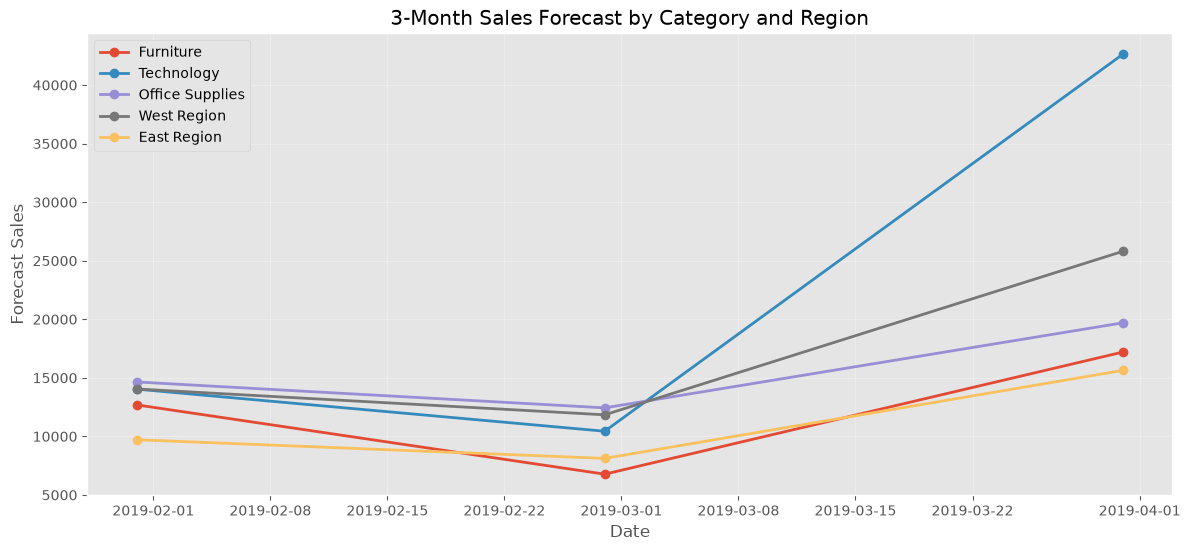

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

for segment in segment_forecast["Segment"].unique():

    temp = segment_forecast[
        segment_forecast["Segment"] == segment
    ]

    plt.plot(
        temp["ds"],
        temp["yhat"],
        marker="o",
        linewidth=2,
        label=segment
    )


plt.title("3-Month Sales Forecast by Category and Region")

plt.xlabel("Date")
plt.ylabel("Forecast Sales")

plt.legend()

plt.grid(alpha=0.3)


plt.savefig(
    "C:/SalesForecasting_Kamali/charts/category_region_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [100]:
growth = (
    segment_forecast
    .groupby("Segment")["yhat"]
    .sum()
    .sort_values(ascending=False)
)

growth

Segment
Technology         67110.818010
West Region        51694.510436
Office Supplies    46779.536462
Furniture          36664.570732
East Region        33473.051287
Name: yhat, dtype: float64

In [101]:
segment_forecast.to_csv("segment_forecast.csv", index=False)

## Category & Region Forecast Analysis

The Prophet forecasting model was applied separately to major product categories and regions.

Based on the 3-month forecast:

- The segment with the highest expected sales is Technology.
- This indicates stronger upcoming demand and may require increased inventory availability.
- Lower-performing segments should be monitored to avoid excess stock accumulation.

The forecast helps in category-level planning and regional inventory optimization. Completed task 4

In [102]:
weekly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="W"
        )
    )["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [103]:
from sklearn.ensemble import IsolationForest

In [104]:
iso_data = weekly_sales[["Sales"]]

In [105]:
iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Isolation_Result"] = iso_model.fit_predict(
    iso_data
)

In [106]:
weekly_sales["Isolation_Anomaly"] = weekly_sales["Isolation_Result"].apply(
    lambda x: "Anomaly" if x == -1 else "Normal"
)

weekly_sales.head()

,Order Date,Sales,Isolation_Result,Isolation_Anomaly
0,2015-01-04,304.508,-1,Anomaly
1,2015-01-11,4619.108,1,Normal
2,2015-01-18,4130.533,1,Normal
3,2015-01-25,3092.544,1,Normal
4,2015-02-01,2527.914,1,Normal


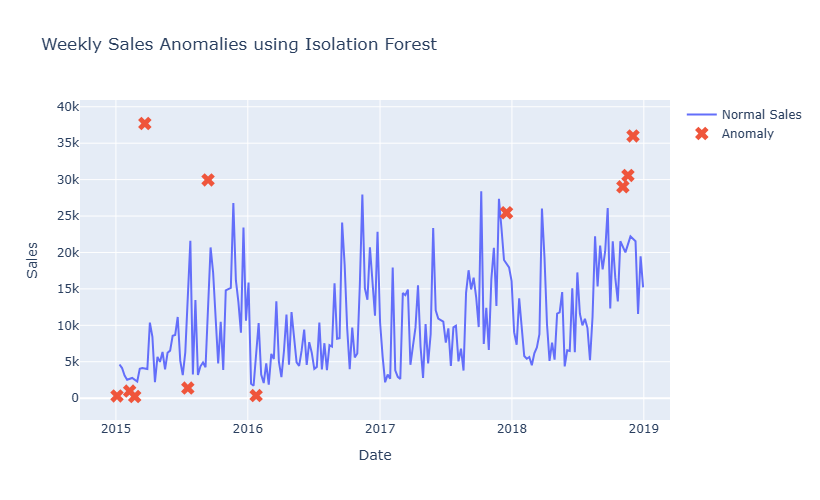

In [107]:
import plotly.graph_objects as go


fig = go.Figure()


# Normal sales
normal = weekly_sales[
    weekly_sales["Isolation_Anomaly"] == "Normal"
]


# Anomaly sales
anomaly = weekly_sales[
    weekly_sales["Isolation_Anomaly"] == "Anomaly"
]


fig.add_trace(
    go.Scatter(
        x=normal["Order Date"],
        y=normal["Sales"],
        mode="lines",
        name="Normal Sales"
    )
)


fig.add_trace(
    go.Scatter(
        x=anomaly["Order Date"],
        y=anomaly["Sales"],
        mode="markers",
        name="Anomaly",
        marker=dict(
            symbol="x",
            size=12
        )
    )
)


fig.update_layout(
    title="Weekly Sales Anomalies using Isolation Forest",
    xaxis_title="Date",
    yaxis_title="Sales",
    hovermode="x unified",
    height=500
)


fig.show()

In [108]:
weekly_sales["Rolling_Mean"] = (
    weekly_sales["Sales"]
    .rolling(window=4)
    .mean()
)

weekly_sales["Rolling_STD"] = (
    weekly_sales["Sales"]
    .rolling(window=4)
    .std()
)

In [109]:
weekly_sales["Z_score"] = (
    (weekly_sales["Sales"] -
     weekly_sales["Rolling_Mean"])
    /
    weekly_sales["Rolling_STD"]
)

In [110]:
weekly_sales["Z_Anomaly"] = np.where(
    abs(weekly_sales["Z_score"]) > 2,
    "Anomaly",
    "Normal"
)

In [111]:
weekly_sales[
    weekly_sales["Z_Anomaly"]=="Anomaly"
]

,Order Date,Sales,Isolation_Result,Isolation_Anomaly,Rolling_Mean,Rolling_STD,Z_score,Z_Anomaly


In [112]:
comparison_anomaly = weekly_sales[
    [
        "Order Date",
        "Sales",
        "Isolation_Anomaly",
        "Z_Anomaly"
    ]
]

comparison_anomaly.head()

,Order Date,Sales,Isolation_Anomaly,Z_Anomaly
0,2015-01-04,304.508,Anomaly,Normal
1,2015-01-11,4619.108,Normal,Normal
2,2015-01-18,4130.533,Normal,Normal
3,2015-01-25,3092.544,Normal,Normal
4,2015-02-01,2527.914,Normal,Normal


In [113]:
comparison_anomaly.to_csv(
    "C:/SalesForecasting_Kamali/anomaly_report.csv",
    index=False
)

In [114]:
common = weekly_sales[
    (weekly_sales["Isolation_Anomaly"]=="Anomaly") &
    (weekly_sales["Z_Anomaly"]=="Anomaly")
]

common

,Order Date,Sales,Isolation_Result,Isolation_Anomaly,Rolling_Mean,Rolling_STD,Z_score,Z_Anomaly


In [115]:
print(
    "Isolation Forest anomalies:",
    len(
        weekly_sales[
            weekly_sales["Isolation_Anomaly"]=="Anomaly"
        ]
    )
)

print(
    "Z-score anomalies:",
    len(
        weekly_sales[
            weekly_sales["Z_Anomaly"]=="Anomaly"
        ]
    )
)

Isolation Forest anomalies: 11
Z-score anomalies: 0


In [116]:
weekly_sales[
    weekly_sales["Isolation_Anomaly"]=="Anomaly"
][
    ["Order Date","Sales"]
]

,Order Date,Sales
0,2015-01-04,304.508
5,2015-02-08,968.534
7,2015-02-22,224.912
11,2015-03-22,37703.665
28,2015-07-19,1387.686
...,...,...
55,2016-01-24,358.522
154,2017-12-17,25449.800
200,2018-11-04,29017.467
202,2018-11-18,30572.447


In [117]:
weekly_sales.to_csv(
    "C:/SalesForecasting_Kamali/weekly_sales.csv",
    index=False
)

In [118]:
weekly_sales[
    weekly_sales["Z_Anomaly"]=="Anomaly"
][
    ["Order Date","Sales"]
]

,Order Date,Sales


## Anomaly Detection Results

Isolation Forest identified several unusual sales weeks, including both extremely low and extremely high sales periods.

The Z-score based method did not detect any anomalies because none of the weekly sales values deviated more than 2 standard deviations from the rolling mean.

The two approaches produced different results:

- Isolation Forest detected anomalies based on the overall pattern of the dataset and was able to identify unusual sales behavior.
- Z-score was more conservative because it only considers statistical distance from the rolling average.

The disagreement shows that machine learning based anomaly detection can capture complex patterns that simple statistical methods may miss.

Possible business explanations for detected anomalies:
- March 2015 sales spike may be due to promotional campaigns or bulk purchases.
- November–December 2018 spikes may correspond to festive season sales, holiday discounts, or increased customer demand.
- Very low sales weeks may be caused by fewer orders, seasonal slowdown, or temporary demand changes.
Completed task 5

In [119]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Year', 'Month', 'Month Name', 'Quarter',
       'Week', 'Day', 'Season', 'Shipping Days'],
      dtype='str')

In [120]:
subcategory_monthly = (
    df.groupby(
        [
            "Sub-Category",
            pd.Grouper(
                key="Order Date",
                freq="ME"
            )
        ]
    )
    ["Sales"]
    .sum()
    .reset_index()
)

subcategory_monthly.head()

,Sub-Category,Order Date,Sales
0,Accessories,2015-01-31,827.890
1,Accessories,2015-02-28,1120.990
2,Accessories,2015-03-31,957.734
3,Accessories,2015-04-30,2323.700
4,Accessories,2015-05-31,695.490


In [121]:
total_sales = (
    subcategory_monthly
    .groupby("Sub-Category")["Sales"]
    .sum()
    .rename("Total_Sales")
)

In [122]:
volatility = (
    subcategory_monthly
    .groupby("Sub-Category")["Sales"]
    .std()
    .rename("Sales_Volatility")
)

In [123]:
yearly_sales = (
    df.groupby(
        [
            "Sub-Category",
            df["Order Date"].dt.year
        ]
    )["Sales"]
    .sum()
    .reset_index()
)

In [124]:
growth = (
    yearly_sales
    .groupby("Sub-Category")["Sales"]
    .pct_change()
    .groupby(yearly_sales["Sub-Category"])
    .mean()
    .rename("Sales_Growth")
)

In [125]:
avg_order = (
    df.groupby("Sub-Category")["Sales"]
    .mean()
    .rename("Average_Order_Value")
)

In [126]:
cluster_df = pd.concat(
    [
        total_sales,
        growth,
        volatility,
        avg_order
    ],
    axis=1
)

cluster_df

,Total_Sales,Sales_Growth,Sales_Volatility,Average_Order_Value
Sub-Category,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175
Appliances,104618.4030,0.399276,1821.621539,227.926804
Art,26705.4100,0.166056,330.488343,34.019631
Binders,200028.7850,0.218736,3848.223648,134.067550
Bookcases,113813.1987,0.238065,2220.405080,503.598224
...,...,...,...,...
Paper,76828.3040,0.254131,1024.824982,57.420257
Phones,327782.4480,0.123409,4052.718221,374.180877
Storage,219343.3920,0.131799,2822.084310,263.633885


In [127]:
cluster_df = cluster_df.fillna(0)

cluster_df.head()

,Total_Sales,Sales_Growth,Sales_Volatility,Average_Order_Value
Sub-Category,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175
Appliances,104618.4030,0.399276,1821.621539,227.926804
Art,26705.4100,0.166056,330.488343,34.019631
Binders,200028.7850,0.218736,3848.223648,134.067550
Bookcases,113813.1987,0.238065,2220.405080,503.598224


In [128]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    cluster_df
)

C:\Users\ADMIN\anaconda3\envs\forecasting\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ADMIN\anaconda3\envs\forecasting\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ADMIN\anaconda3\envs\forecasting\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ADMIN\anaconda3\envs\forecasting\Lib\site-packages\sklearn\cluster\_kmeans.p

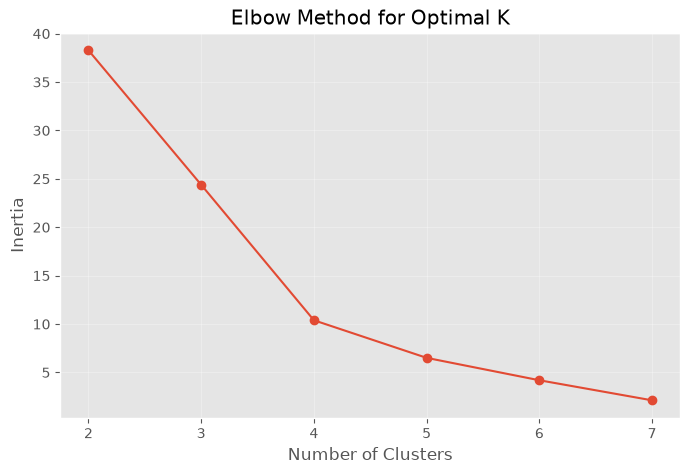

In [129]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2,8):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    inertia.append(
        kmeans.inertia_
    )


plt.figure(figsize=(8,5))

plt.plot(
    range(2,8),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title(
    "Elbow Method for Optimal K"
)

plt.grid(alpha=0.3)

plt.show()

In [130]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_df["Cluster"] = kmeans.fit_predict(
    scaled_features
)

cluster_df.head()

C:\Users\ADMIN\anaconda3\envs\forecasting\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Total_Sales,Sales_Growth,Sales_Volatility,Average_Order_Value,Cluster
Sub-Category,,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175,2
Appliances,104618.4030,0.399276,1821.621539,227.926804,1
Art,26705.4100,0.166056,330.488343,34.019631,1
Binders,200028.7850,0.218736,3848.223648,134.067550,2
Bookcases,113813.1987,0.238065,2220.405080,503.598224,1


In [131]:
cluster_df.groupby("Cluster").apply(
    lambda x: x.index.tolist()
)

Cluster
0                                  [Copiers, Machines]
1    [Appliances, Art, Bookcases, Envelopes, Fasten...
2    [Accessories, Binders, Chairs, Phones, Storage...
3                                           [Supplies]
dtype: object

In [132]:
cluster_summary = (
    cluster_df
    .groupby("Cluster")
    .mean()
)

cluster_summary

,Total_Sales,Sales_Growth,Sales_Volatility,Average_Order_Value
Cluster,,,,
0,167743.362500,0.463389,5552.164569,1930.716763
1,55331.883212,0.199589,907.223743,129.054568
2,239495.780667,0.180965,3489.056075,361.131228
3,46420.308000,1.928448,2025.094139,252.284283


In [133]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2
)

pca_result = pca.fit_transform(
    scaled_features
)

cluster_df["PCA1"] = pca_result[:,0]
cluster_df["PCA2"] = pca_result[:,1]

In [135]:
cluster_df.to_csv(
    "C:/SalesForecasting_Kamali/product_clusters.csv",
    index=True
)

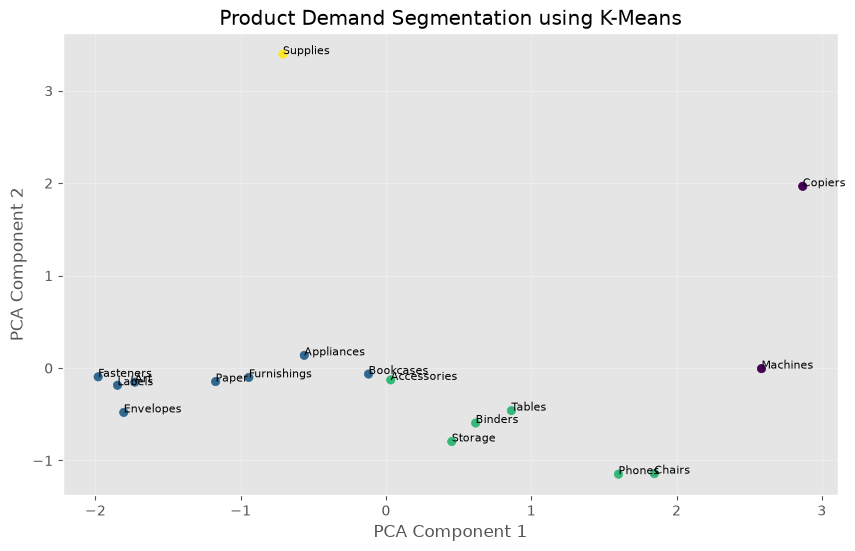

In [136]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

pca_result = pca.fit_transform(
    scaled_features
)

cluster_df["PCA1"] = pca_result[:,0]
cluster_df["PCA2"] = pca_result[:,1]


plt.figure(figsize=(10,6))

plt.scatter(
    cluster_df["PCA1"],
    cluster_df["PCA2"],
    c=cluster_df["Cluster"]
)


for i, name in enumerate(cluster_df.index):
    plt.text(
        cluster_df["PCA1"].iloc[i],
        cluster_df["PCA2"].iloc[i],
        name,
        fontsize=8
    )


plt.title(
    "Product Demand Segmentation using K-Means"
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.grid(alpha=0.3)

plt.savefig(
    "C:/SalesForecasting_Kamali/charts/product_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Product Demand Segmentation Analysis

K-Means clustering was applied to sub-category level sales data using total sales volume, sales growth rate, sales volatility, and average order value.

Four demand segments were identified:

1. High Value, Premium Demand:
   - Includes Copiers and Machines.
   - These products generate high revenue with high order value but variable demand.
   - Strategy: Maintain safety stock and closely monitor demand.

2. Low Volume, Stable Demand:
   - Contains products with lower sales but predictable patterns.
   - Strategy: Use regular replenishment policies.

3. High Volume, Core Products:
   - These products contribute the highest overall revenue.
   - Strategy: Prioritize inventory availability to avoid stockouts.

4. Growing Demand Products:
   - Products showing strong growth trends.
   - Strategy: Increase inventory gradually based on future demand.
Task 6 is Completed